In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
df_player = pd.read_csv('data/world_tva.csv')
df_player.head()

,number,name,position,age,nationality,team,value
0,1,Lamine Yamal,Right Winger,18,Spain,FC Barcelona,200.0
1,2,Erling Haaland,Centre-Forward,25,Norway,Manchester City,200.0
2,3,Kylian Mbappé,Centre-Forward,27,France,Real Madrid,200.0
3,4,Jude Bellingham,Attacking Midfield,22,England,Real Madrid,160.0
4,5,Vinicius Junior,Left Winger,25,Brazil,Real Madrid,150.0


In [3]:
df_player = df_player.rename(columns={'value': 'VALUE_EURO'})
df_player['VALUE_KRW'] = df_player['VALUE_EURO'] * 13 # 대략 1유로 = 1300

# 컬럼명을 전부 대문자로 변환 (코딩하기 편하게)
df_player.columns = [col.upper() for col in df_player.columns]

cols = ['NUMBER', 'NAME', 'POSITION', 'AGE', 'NATIONALITY', 'TEAM', 'VALUE_EURO', 'VALUE_KRW']
df_player = df_player[cols]

df_player.head()

,NUMBER,NAME,POSITION,AGE,NATIONALITY,TEAM,VALUE_EURO,VALUE_KRW
0,1,Lamine Yamal,Right Winger,18,Spain,FC Barcelona,200.0,2600.0
1,2,Erling Haaland,Centre-Forward,25,Norway,Manchester City,200.0,2600.0
2,3,Kylian Mbappé,Centre-Forward,27,France,Real Madrid,200.0,2600.0
3,4,Jude Bellingham,Attacking Midfield,22,England,Real Madrid,160.0,2080.0
4,5,Vinicius Junior,Left Winger,25,Brazil,Real Madrid,150.0,1950.0


In [4]:
# 1. 간단하게 일단 몸값 상위 top_50
top_50 = df_player.nlargest(50,'VALUE_KRW')
print(top_50)


    NUMBER                   NAME            POSITION  AGE  NATIONALITY  \
0        1           Lamine Yamal        Right Winger   18        Spain   
1        2         Erling Haaland      Centre-Forward   25       Norway   
2        3          Kylian Mbappé      Centre-Forward   27       France   
3        4        Jude Bellingham  Attacking Midfield   22      England   
4        5        Vinicius Junior         Left Winger   25       Brazil   
5        6                  Pedri    Central Midfield   23        Spain   
6        7          Jamal Musiala  Attacking Midfield   22      Germany   
7        8          Michael Olise        Right Winger   24       France   
8        9            Bukayo Saka        Right Winger   24      England   
9       10            Cole Palmer  Attacking Midfield   23      England   
10      11      Federico Valverde    Central Midfield   27      Uruguay   
11      12            Declan Rice    Central Midfield   27      England   
12      13         Alexan

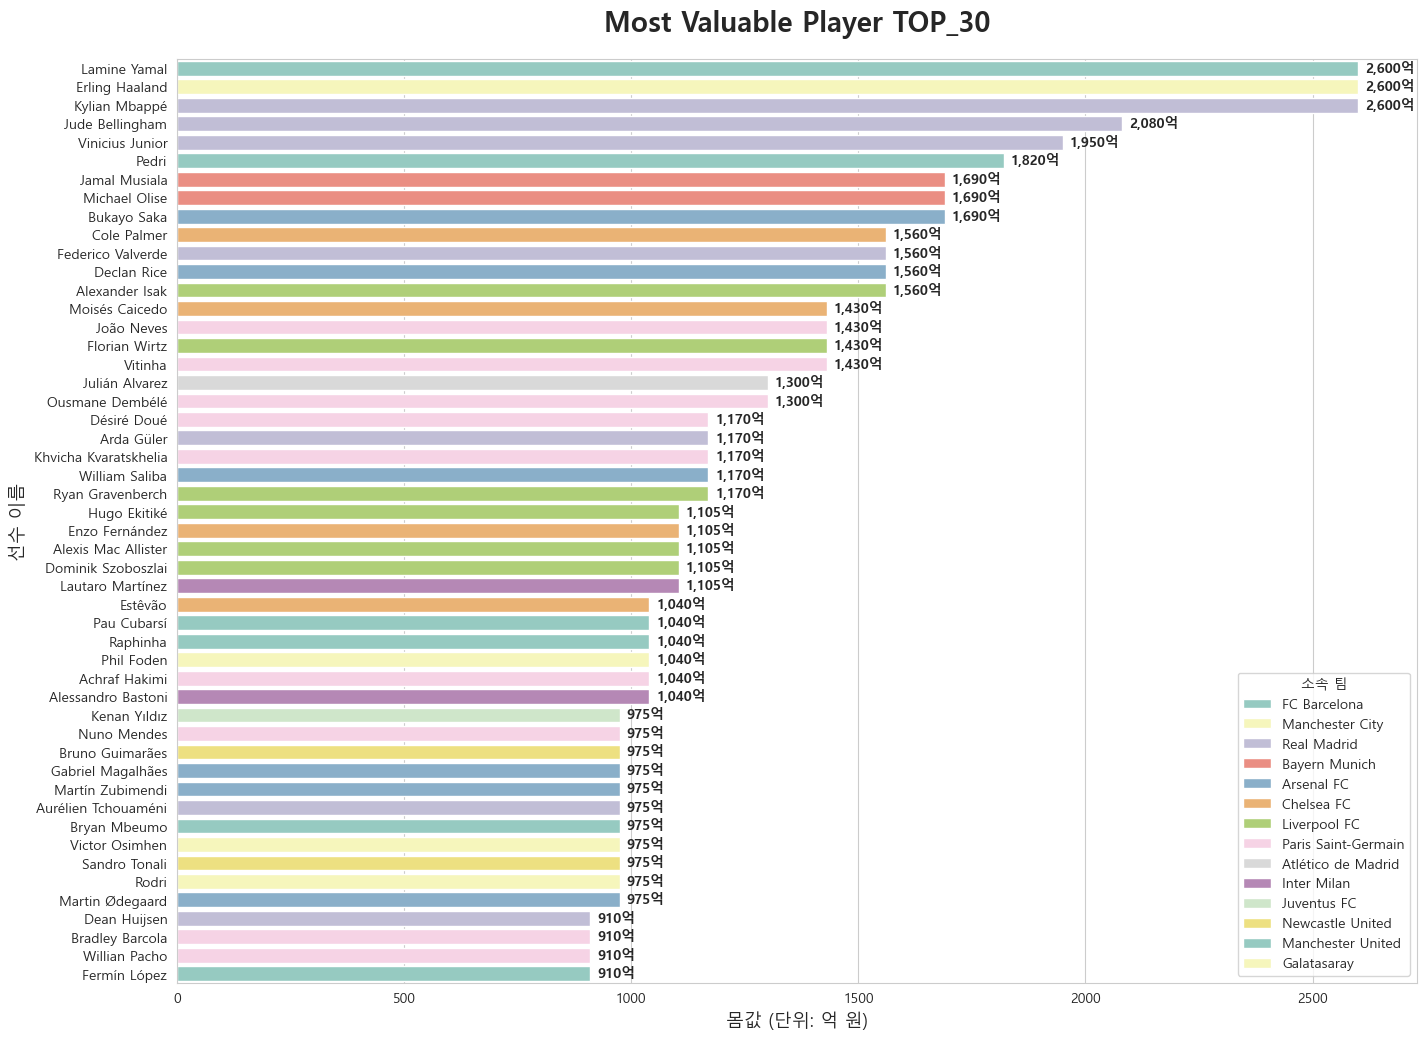

In [5]:
plt.figure(figsize=(16,12))
sns.set_style('whitegrid')
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
ax = sns.barplot(
  data=top_50,
  x='VALUE_KRW',
  y='NAME',
  hue='TEAM',
  palette='Set3',
  dodge=False # hue 사용 시 막대가 얇아지는것 방지
)

for p in ax.patches:
  width = p.get_width()
  if width > 0: # 0보다 큰 경우만 표시
    ax.annotate(f'{int(width):,}억',
                (width, p.get_y() + p.get_height()/2),
                ha='left', va='center',
                xytext=(5,0), textcoords='offset points',
                fontsize=10, fontweight='bold'
                )

plt.title("Most Valuable Player TOP_30", fontsize=20, pad=20,fontweight='bold')
plt.xlabel('몸값 (단위: 억 원)', fontsize=13)
plt.ylabel('선수 이름',fontsize=13)

plt.legend(title='소속 팀')

plt.show()